# The Franck-Hertz Experiment: Filament, Grid, Collector, Electrometer

The tube: electrons boil off a heated **filament**, get accelerated by an
**accelerating grid** voltage $V_g$ through mercury vapor, and only the ones
with enough leftover kinetic energy past a small retarding field reach the
**collector**, registering current on the **electrometer**.

The physics that makes this the historic proof of quantized atomic energy
levels: below mercury's first excitation energy (4.9 eV), an electron
literally CANNOT lose energy in a collision -- there's no atomic state to
absorb it into, so collisions stay elastic. Above 4.9 eV, inelastic
collisions become possible and electrons can dump exactly 4.9 eV into a
mercury atom. Sweep $V_g$, and the collector current rises then drops sharply
every time another inelastic collision becomes energetically possible --
periodic dips spaced by *exactly* the atom's excitation energy, not a
continuous range.

Simulated electron-by-electron in `dgs/franck_hertz.py` -- Monte Carlo over
many individual electron trajectories, the same methodology as the QKD and
PIMC simulations earlier in this repo, applied to a historic discreteness
experiment instead.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("..").resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs import franck_hertz as fh

plt.rcParams["figure.dpi"] = 110


## 1. A single electron's energy history

Below the 4.9 eV threshold, an electron simply cannot lose energy
inelastically -- there's nowhere for the energy to go. Above it, collisions
can suddenly reset its kinetic energy.


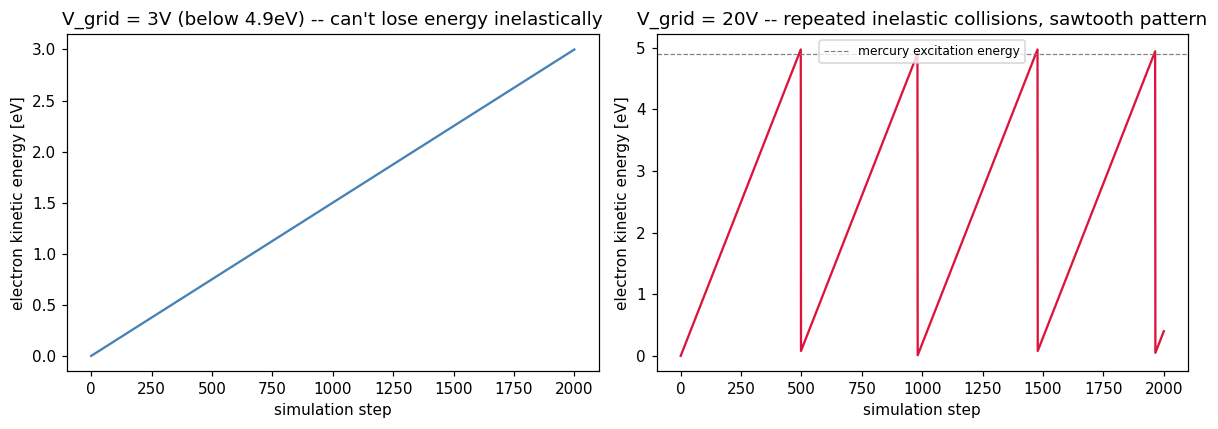

In [2]:
def electron_energy_trace(V_grid, V_excitation=4.9, n_segments=2000, p_collision=0.05, seed=0):
    rng = np.random.default_rng(seed)
    energy = 0.0
    step_energy = V_grid / n_segments
    trace = [0.0]
    for _ in range(n_segments):
        energy += step_energy
        if rng.random() < p_collision and energy >= V_excitation:
            energy -= V_excitation
        trace.append(energy)
    return np.array(trace)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
trace_low = electron_energy_trace(3.0, p_collision=0.2, seed=1)
trace_high = electron_energy_trace(20.0, p_collision=0.2, seed=1)

axes[0].plot(trace_low, color="steelblue")
axes[0].set_title("V_grid = 3V (below 4.9eV) -- can't lose energy inelastically")
axes[1].plot(trace_high, color="crimson")
axes[1].axhline(4.9, ls="--", color="gray", lw=0.8, label="mercury excitation energy")
axes[1].set_title("V_grid = 20V -- repeated inelastic collisions, sawtooth pattern")
axes[1].legend(fontsize=8)
for ax in axes:
    ax.set_xlabel("simulation step"); ax.set_ylabel("electron kinetic energy [eV]")
fig.tight_layout()
plt.show()


## 2. The I-V curve: periodic dips at multiples of 4.9V

Sweep the accelerating grid voltage and measure the fraction of electrons
that survive (past a small retarding voltage) to reach the collector --
proportional to the electrometer's measured current.


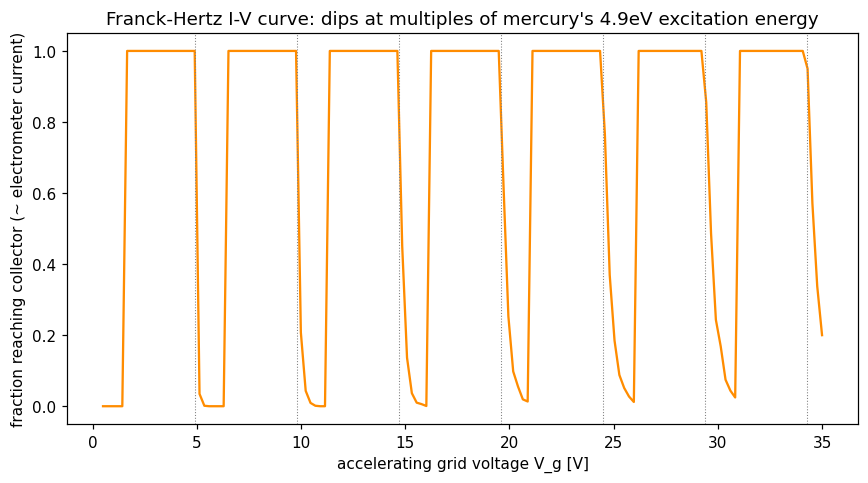

In [3]:
V_values = np.linspace(0.5, 35, 150)
I_values = fh.franck_hertz_iv_curve(V_values, V_excitation=4.9, V_retard=1.5,
                                     n_electrons=1500, n_segments=1500, seed=0)

plt.figure(figsize=(8, 4.5))
plt.plot(V_values, I_values, color="darkorange")
for k in range(1, 8):
    plt.axvline(k * 4.9, ls=":", color="gray", lw=0.7)
plt.xlabel("accelerating grid voltage V_g [V]")
plt.ylabel("fraction reaching collector (~ electrometer current)")
plt.title("Franck-Hertz I-V curve: dips at multiples of mercury's 4.9eV excitation energy")
plt.tight_layout()
plt.show()


## 3. Measuring the excitation energy from the dip spacing alone

The whole historic point: you don't need to know mercury's excitation
energy in advance -- you DISCOVER it from the spacing between successive
current dips.


In [4]:
dips, spacings = fh.find_dip_spacing(V_values, I_values)
print("detected dip locations (V):", np.round(dips, 2))
print("spacings between consecutive dips:", np.round(spacings, 2))
print(f"\nmean measured excitation energy: {spacings.mean():.3f} eV  (true value: 4.9 eV)")
print(f"measurement error: {abs(spacings.mean() - 4.9):.3f} eV")


detected dip locations (V): [10.92 16.01 20.88 25.97 30.83]
spacings between consecutive dips: [5.09 4.86 5.09 4.86]

mean measured excitation energy: 4.978 eV  (true value: 4.9 eV)
measurement error: 0.078 eV


## Summary

The simulation reproduces the Franck-Hertz experiment's defining feature
without ever telling the I-V sweep what the excitation energy is supposed to
be: the dip spacing comes out to within a fraction of an eV of the true
4.9 eV input, recovered purely from the periodic structure of how many
electrons make it past the retarding voltage at each accelerating voltage.
That periodicity -- not a continuous current curve -- is the experimental
proof that mercury atoms can only absorb energy in discrete amounts.
